In [1]:
import scanpy as sc

# Check Morely human ped. dev. h5ad file

In [2]:
zdata = sc.read_h5ad("/data/pintardde/combined_marker_pipeline/data/UPENN_PedDev_seurat.h5ad")

In [30]:
zdata

AnnData object with n_obs × n_vars = 313150 × 36601
    obs: 'library_id', 'nCount_RNA', 'nFeature_RNA', 'scrublet_score', 'scrublet_call', 'cxds_score', 'cxds_call', 'bcds_score', 'bcds_call', 'hybrid_score', 'hybrid_call', 'percent.mito', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'LMCR.lineage_level1.score', 'LMCR.lineage_level1', 'LMCR.lineage_level2.score', 'LMCR.lineage_level2', 'LMCR.celltype_level1.score', 'LMCR.celltype_level1', 'LMCR.celltype_level2.score', 'LMCR.celltype_level2', 'LMCR.celltype_level3.score', 'LMCR.celltype_level3', 'HLCA_ann_level_1.score', 'HLCA_ann_level_1', 'HLCA_ann_level_2.score', 'HLCA_ann_level_2', 'HLCA_ann_level_3.score', 'HLCA_ann_level_3', 'HLCA_ann_level_4.score', 'HLCA_ann_level_4', 'HLCA_ann_level_5.score', 'HLCA_ann_level_5', 'HLCA_ann_finest_level.score', 'HLCA_ann_finest_level', 'mapping.score', 'donor_id', 'species', 'alive_at_collection', 'genotype', 'diseases', 'sex', 'age', 'age_unit', 'development

In [21]:
sc.pp.neighbors(zdata, random_state=23)
sc.tl.umap(zdata, random_state=23)

/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
zdata

AnnData object with n_obs × n_vars = 313150 × 36601
    obs: 'library_id', 'nCount_RNA', 'nFeature_RNA', 'scrublet_score', 'scrublet_call', 'cxds_score', 'cxds_call', 'bcds_score', 'bcds_call', 'hybrid_score', 'hybrid_call', 'percent.mito', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'LMCR.lineage_level1.score', 'LMCR.lineage_level1', 'LMCR.lineage_level2.score', 'LMCR.lineage_level2', 'LMCR.celltype_level1.score', 'LMCR.celltype_level1', 'LMCR.celltype_level2.score', 'LMCR.celltype_level2', 'LMCR.celltype_level3.score', 'LMCR.celltype_level3', 'HLCA_ann_level_1.score', 'HLCA_ann_level_1', 'HLCA_ann_level_2.score', 'HLCA_ann_level_2', 'HLCA_ann_level_3.score', 'HLCA_ann_level_3', 'HLCA_ann_level_4.score', 'HLCA_ann_level_4', 'HLCA_ann_level_5.score', 'HLCA_ann_level_5', 'HLCA_ann_finest_level.score', 'HLCA_ann_finest_level', 'mapping.score', 'donor_id', 'species', 'alive_at_collection', 'genotype', 'diseases', 'sex', 'age', 'age_unit', 'development

In [18]:
age_series = zdata.obs['age'].value_counts()
age_series.index = age_series.index.astype(int) / 365
age_series

age
0.180822     31330
0.000000     21839
2.301370     16288
0.002740     15909
0.167123     15445
0.082192     15433
0.046575     15430
0.178082     14289
2.219178     13606
0.134247     13586
39.000000    12625
0.328767     11567
0.657534     11532
35.000000    11532
0.019178     11225
0.063014     10463
29.000000    10020
0.115068      9881
13.000000     8236
0.410959      7635
42.000000     7189
25.000000     6718
0.071233      5392
0.821918      5012
12.000000     4361
0.164384      3652
17.000000     2955
Name: count, dtype: int64

In [31]:
# filter out mature subset. I am chosing 5478.75/15 years as my cut off since that is the same cut off that is used for Anne's cellharvester package filters
# adata objects to contain cells from donors who are 15 years or older

age_cutoff = 5478.75

aadata = zdata[zdata.obs['age'] > age_cutoff].copy()
aadata.write_h5ad("/data/pintardde/combined_marker_pipeline/data/UPENN_PedDev_seurat_adult.h5ad")

In [37]:
aadata.obs['library_platform'].unique()

['10x 3' v3', '10x 3' v2']
Categories (2, object): ['10x 3' v2', '10x 3' v3']

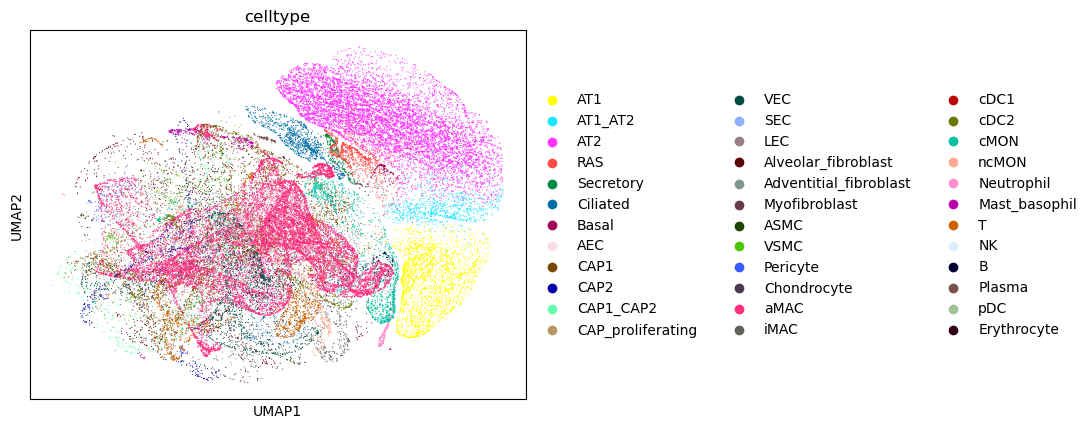

In [27]:
sc.pl.umap(
    aadata, 
    color = ['celltype'])

# ['celltype', 'subtype', 'cellrefname', 'HLCA_ann_finest_level', 'LMCR.celltype_level3']

## Check Raredon rat data h5ad file

In [4]:
raredon_rat = "/data/pintardde/class_marker_pipeline/data/rat.lung.Raredon-2019.2026-04-30.h5ad"
adata = sc.read_h5ad(raredon_rat)

In [53]:
adata.obs['Dataset'].unique()

['10x_v2']
Categories (1, object): ['10x_v2']

In [14]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_GeneFull,nFeature_GeneFull,nCount_spliced,nFeature_spliced,nCount_unspliced,nFeature_unspliced,percent.mt,perc.spliced,Sample,Dataset,LM_Type,Sex,Class.pub,Type.pub.updated,annotation_2019
fRat__AAACCTGAGAACTGTA,fRat,7069.0,1972.0,8347.0,2648,6211.0,1777,1186.0,832,5.531193,83.966473,fRat,10x_v2,Myeloid,Female,Myeloid,Activated-Alveolar-Macrophages,Mac_alv
fRat__AAACCTGCAACGATCT,fRat,3183.0,1076.0,4056.0,1639,2890.0,964,768.0,588,4.901037,79.004921,fRat,10x_v2,Myeloid,Female,Myeloid,Dendritic-Cells-Type-2,DC_Ccl17+
fRat__AAACCTGCATTAGGCT,fRat,638.0,284.0,748.0,362,587.0,252,84.0,78,0.783699,87.481371,fRat,10x_v2,Myeloid,Female,Myeloid,Neutrophils,NaN
fRat__AAACGGGAGCCATCGC,fRat,14414.0,2908.0,15860.0,3493,12574.0,2626,1373.0,814,4.863327,90.155589,fRat,10x_v2,Myeloid,Female,Myeloid,Activated-Alveolar-Macrophages,Mac_alv
fRat__AAACGGGCAGTTCCCT,fRat,4230.0,1364.0,4975.0,1772,3783.0,1235,647.0,450,3.475177,85.395034,fRat,10x_v2,Myeloid,Female,Myeloid,Monocytes-Classical,Mo_Ly6c+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mRat__TTGGAACTCTATGTGG,mRat,925.0,488.0,1043.0,590,843.0,439,119.0,106,1.297297,87.629938,mRat,10x_v2,NaN,Male,Mesenchyme,Mesothelium,Meso
mRat__TTTACTGCAGCTTCGG,mRat,9671.0,2634.0,11124.0,3356,8596.0,2374,1334.0,917,4.404922,86.565962,mRat,10x_v2,NaN,Male,Mesenchyme,Mesothelium,Meso
mRat__TTTCCTCTCAGCAACT,mRat,2711.0,1182.0,3472.0,1622,2531.0,1105,690.0,490,5.864994,78.578081,mRat,10x_v2,NaN,Male,Mesenchyme,Mesothelium,Meso
mRat__TTTCCTCTCTTGTCAT,mRat,4754.0,1681.0,5443.0,2063,4304.0,1545,599.0,419,1.430374,87.782990,mRat,10x_v2,NaN,Male,Mesenchyme,Adventitial-Fibroblasts,Fib_Col14a1+


In [50]:
# check `Type.pub.updated` field to get endothelial cell types
adata.obs[adata.obs['Class.pub'] == 'Endothelium']['Type.pub.updated'].unique()

['gCap', 'Arterial-Endothelium', 'Venous-Endothelium', 'aCap', 'Lymphatic-Endothelium', 'Cycling-Endothelium']
Categories (47, object): ['ATI', 'ATII', 'Activated-Alveolar-Macrophages', 'Activated-Mesothelium', ..., 'Vascular-SMCs', 'Venous-Endothelium', 'aCap', 'gCap']

Endothelial cell types in `Type.pub.updated`: Arterial-Endothelium,Venous-Endothelium,aCap,gCap,Lymphatic-Endothelium,Cycling-Endothelium

In [20]:
# check `` field to get endothelial cell types
adata.obs[adata.obs['Class.pub'] == 'Endothelium']['annotation_2019'].unique()
# adata.obs['annotation_2019'].unique().tolist()

['EC_vasc', 'EC_Vcam1+', 'EC_cap', NaN, 'EC_lymph', 'ATI', 'Mac_alv', 'T_cells']
Categories (25, object): ['ATI', 'ATII', 'B_cells', 'Ciliated', ..., 'Secretory', 'Sox9+', 'T_CD8+', 'T_cells']

Endothelial cell types in `annotation_2019`: EC_vasc,EC_Vcam1+,EC_cap,EC_lymph

In [23]:
adata.var

,gene_ids
AABR07000046.1,AABR07000046.1
AABR07000089.1,AABR07000089.1
Vom2r6,Vom2r6
Vom2r5,Vom2r5
Raet1e,Raet1e
...,...
AABR07022926.1,AABR07022926.1
AABR07046563.1,AABR07046563.1
LOC100910067,LOC100910067
AABR07045682.1,AABR07045682.1


## Check Schupp et al. data 

In [21]:
schupp_mouse1 = "/data/pintardde/class_marker_pipeline/data/mouse.clean.08_06_20.h5ad"
schupp_mouse2 = "/data/pintardde/class_marker_pipeline/data/mouse_EC.clean.integrated.05_06_2020.h5ad"

adata1 = sc.read_h5ad(schupp_mouse1)
adata2 = sc.read_h5ad(schupp_mouse2)

In [56]:
adata1.obsm['X_pca']

array([[  2.47603687,   8.25347497],
       [ -2.01808348,  12.16111257],
       [ -2.03227177,   1.99869325],
       ...,
       [  8.78496346,  -4.02307317],
       [ -0.52868644,   5.73454692],
       [-13.99520222,  -3.74105475]], shape=(57974, 2))

In [24]:
adata2

AnnData object with n_obs × n_vars = 21343 × 39541
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'integrated_snn_res.0.8', 'seurat_clusters', 'integrated_snn_res.1', 'integrated_snn_res.1.2', 'cell.type.ident', 'cohort.ident', 'integrated_snn_res.1.5', 'integrated_snn_res.1.8'
    var: 'gene_ids'
    obsm: 'X_pca'

In [40]:
adata1.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,integrated_snn_res.0.8,seurat_clusters,integrated_snn_res.1,integrated_snn_res.1.2,cell.type.ident,cell.type.ident.old,lineage.ident,cohort.ident
CDKPEI180829001__AAACCTGAGACGCACA,CDKPEI180829001,6826.500000,3298,0.187905,33,19,17,19,EC_arterial,EC_arterial,endothelial,Kalucka_et_al
CDKPEI180829001__AAACCTGCAACTGGCC,CDKPEI180829001,3642.300000,2057,0.030647,6,7,6,7,EC_capillary_A,EC_capillary_A,endothelial,Kalucka_et_al
CDKPEI180829001__AAACCTGCACATTAGC,CDKPEI180829001,2699.100000,1636,0.490910,7,9,7,9,EC_capillary_B,EC_capillary_B,endothelial,Kalucka_et_al
CDKPEI180829001__AAACCTGGTTACGTCA,CDKPEI180829001,6560.100000,3139,0.236119,6,7,6,7,EC_capillary_A,EC_capillary_A,endothelial,Kalucka_et_al
CDKPEI180829001__AAACCTGTCTCTAGGA,CDKPEI180829001,6971.400000,3329,0.481491,12,13,14,13,EC_venous,EC_venous,endothelial,Kalucka_et_al
...,...,...,...,...,...,...,...,...,...,...,...,...
Young4Lung__TTTGTCACAGCTGCAC,Young4Lung,1437.421211,878,0.046224,15,20,12,20,T_helper,T_helper,lymphoid,Kimmel_et_al
Young4Lung__TTTGTCAGTCGCTTTC,Young4Lung,1819.656814,1105,0.051509,10,10,10,10,ncMono,Myoloid,myeloid,Kimmel_et_al
Young4Lung__TTTGTCAGTCTCAACA,Young4Lung,1081.206342,731,0.000000,15,20,12,20,T_helper,T_helper,lymphoid,Kimmel_et_al
Young4Lung__TTTGTCAGTTAAGACA,Young4Lung,3275.920626,1961,0.607686,0,0,1,0,EC_capillary_B,EC_capillary_B,endothelial,Kimmel_et_al


In [41]:
adata2.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,integrated_snn_res.0.8,seurat_clusters,integrated_snn_res.1,integrated_snn_res.1.2,cell.type.ident,cohort.ident,integrated_snn_res.1.5,integrated_snn_res.1.8
CDKPEI180829001__AAACCTGAGACGCACA,CDKPEI180829001,6826.500000,3298,0.187905,33,19,17,19,EC_arterial,Kalucka_et_al,19,17
CDKPEI180829001__AAACCTGCAACTGGCC,CDKPEI180829001,3642.300000,2057,0.030647,6,4,6,7,EC_capillary_A,Kalucka_et_al,4,4
CDKPEI180829001__AAACCTGCACATTAGC,CDKPEI180829001,2699.100000,1636,0.490910,7,14,7,9,EC_capillary_B,Kalucka_et_al,14,14
CDKPEI180829001__AAACCTGGTTACGTCA,CDKPEI180829001,6560.100000,3139,0.236119,6,7,6,7,EC_capillary_A,Kalucka_et_al,7,7
CDKPEI180829001__AAACCTGTCTCTAGGA,CDKPEI180829001,6971.400000,3329,0.481491,12,8,14,13,EC_venous,Kalucka_et_al,8,8
...,...,...,...,...,...,...,...,...,...,...,...,...
Young4Lung__TTTGGTTAGTGAAGTT,Young4Lung,1493.051745,1037,0.445240,12,8,14,13,EC_venous,Kimmel_et_al,8,8
Young4Lung__TTTGGTTCAGCCTATA,Young4Lung,2003.596482,1359,0.000000,2,2,2,2,EC_capillary_B,Kimmel_et_al,2,2
Young4Lung__TTTGTCAAGAAACCAT,Young4Lung,1481.387278,1034,0.106720,19,3,19,17,EC_capillary_B,Kimmel_et_al,3,3
Young4Lung__TTTGTCACACGTCTCT,Young4Lung,2227.913151,1396,0.173705,6,4,6,7,EC_capillary_A,Kimmel_et_al,4,4


In [39]:
adata1.obs['cell.type.ident'].cat.categories

Index(['AM', 'AT1', 'AT2', 'B', 'Basal', 'Cell_Cycle', 'Chondrocyte',
       'Ciliated', 'DC_mature', 'EC_arterial', 'EC_bronchial',
       'EC_capillary_A', 'EC_capillary_B', 'EC_lymph', 'EC_venous',
       'Fibroblast_adventitial', 'Fibroblast_alveolar',
       'Fibroblast_peribronchial', 'ILC', 'M', 'Mast', 'Mesothel', 'NG', 'NK',
       'Pericyte', 'Pericyte_SMC', 'Plasma', 'SMC', 'Schwann', 'Secretory',
       'T_cytotox', 'T_gammadelta', 'T_helper', 'T_reg', 'cDC1', 'cDC2',
       'cMono', 'ncMono', 'pDC', 'unclear_Fibro_w_Axon'],
      dtype='object')

In [37]:
adata1.obs['cell.type.ident'].value_counts()

cell.type.ident
EC_capillary_B              14119
B                            8014
EC_capillary_A               4853
T_cytotox                    4263
Fibroblast_alveolar          2998
AT2                          2339
cMono                        2053
ncMono                       2003
NG                           1842
AM                           1825
EC_venous                    1784
NK                           1380
T_helper                     1020
Cell_Cycle                    962
T_reg                         936
cDC2                          715
M                             710
cDC1                          591
Fibroblast_adventitial        523
Mesothel                      508
EC_lymph                      488
EC_arterial                   470
AT1                           464
ILC                           437
Ciliated                      433
Pericyte                      390
SMC                           271
Fibroblast_peribronchial      249
Secretory                     21

In [38]:
adata2.obs['cell.type.ident'].value_counts()

cell.type.ident
EC_capillary_B           14119
EC_capillary_A            4853
EC_venous                 1784
EC_arterial                470
EC_bronchial               117
Multiplet                    0
EC_capillary_inflamed        0
EC_lymph                     0
EC_arterial????              0
Name: count, dtype: int64

In [32]:
adata1.obs[adata1.obs['lineage.ident'] == 'endothelial']['cell.type.ident'].unique().tolist()

['EC_arterial',
 'EC_capillary_A',
 'EC_capillary_B',
 'EC_venous',
 'EC_lymph',
 'EC_bronchial']

In [36]:
adata2.obs['cell.type.ident'].unique()

['EC_arterial', 'EC_capillary_A', 'EC_capillary_B', 'EC_venous', 'EC_bronchial']
Categories (9, object): ['EC_capillary_B', 'EC_capillary_A', 'EC_venous', 'EC_capillary_inflamed', ..., 'EC_lymph', 'EC_arterial', 'EC_arterial????', 'EC_bronchial']

In [35]:
adata2.obs['cell.type.ident'].cat.categories

Index(['EC_capillary_B', 'EC_capillary_A', 'EC_venous',
       'EC_capillary_inflamed', 'Multiplet', 'EC_lymph', 'EC_arterial',
       'EC_arterial????', 'EC_bronchial'],
      dtype='object')

In [47]:
len(adata2.obs.index)

21343

In [48]:
bool_arr = adata2.obs.index.isin(adata1.obs.index)
matched_idx = []
for i in bool_arr:
    if i == False:
        print("mismatched barcode")
    else:
        matched_idx.append(i)

if len(matched_idx) == len(adata2.obs.index):
    print("adata2 is a subset of adata1")

adata2 is a subset of adata1


In [49]:
adata1.var

,gene_ids
4933401J01Rik,4933401J01Rik
Gm26206,Gm26206
Xkr4,Xkr4
Gm18956,Gm18956
Gm1992,Gm1992
...,...
mt-Nd6,mt-Nd6
mt-Te,mt-Te
mt-Cytb,mt-Cytb
mt-Tt,mt-Tt


Endothelial cell types in `cell.type.ident`: EC_arterial,EC_capillary_A,EC_capillary_B,EC_venous,EC_lymph,EC_bronchial

## Fix "_index" column in .var in LungMap CellRef

In [2]:
cellref_path = "/data/ScheuermannGroup/cellxgene/Ajith/cellxgene/LungMAP_HumanLung_CellRef.v1.1.h5ad"
adata = sc.read_h5ad(cellref_path)

In [3]:
adata

AnnData object with n_obs × n_vars = 347970 × 32284
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'S.Score', 'G2M.Score', 'Phase', 'pMT', 'DataID', 'DonorID', 'Dataset', 'Age', 'Sex', 'lineage_level1', 'lineage_level2', 'celltype_level1', 'celltype_level2', 'celltype_level3', 'celltype_level3_fullname'
    var: '_index', 'features'
    obsm: 'X_pca', 'X_umap'

In [4]:
import scipy.sparse as sp
import numpy as np

ds_X = adata.X[:100].copy()
ds_arr = ds_X.toarray() if sp.issparse(ds_X) else ds_X
is_integer = np.allclose(ds_arr, np.round(ds_arr), rtol=1e-5, atol=1e-5)
max_val = ds_arr.max()

if 'log1p' in adata.uns:
    print("Metadata Check: Found 'log1p' in adata.uns. Data is already transformed.")
elif (not is_integer) and max_val < 30: # if matrix is not raw counts andmax value less than 30, then it is transformed
    print(f"Heuristic Check: 'log1p' metadata missing, but data appears transformed (contains floats, max={max_val:.2f}). Skipping.")
else:
    print(f"Heuristic Check: Data appears not to be transformed (contains ints)")
    print('Transforming data...')
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

Heuristic Check: 'log1p' metadata missing, but data appears transformed (contains floats, max=8.11). Skipping.


In [5]:
adata.var

,_index,features
0,MIR1302-2HG,MIR1302-2HG
1,FAM138A,FAM138A
2,OR4F5,OR4F5
3,AL627309.1,AL627309.1
4,AL627309.3,AL627309.3
...,...,...
32279,AC141272.1,AC141272.1
32280,AC023491.2,AC023491.2
32281,AC007325.1,AC007325.1
32282,AC007325.4,AC007325.4


In [6]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_SCT,nFeature_SCT,S.Score,G2M.Score,Phase,pMT,DataID,DonorID,Dataset,Age,Sex,lineage_level1,lineage_level2,celltype_level1,celltype_level2,celltype_level3,celltype_level3_fullname
Donor27_Donor27_AAACGAACACCGTGCA-1,CCHMC_SMG_Donor27,78067.0,5526,18752.0,2854,-0.034438,-0.037647,G1,3.942845,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Epithelial,Epithelial_Glandular,Serous,Serous,Serous,Serous cell
Donor27_Donor27_AAAGAACAGCGCCATC-1,CCHMC_SMG_Donor27,46370.0,4765,18071.0,3371,0.000111,-0.053899,S,6.671827,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Epithelial,Epithelial_Glandular,Serous,Serous,Serous,Serous cell
Donor27_Donor27_AAAGAACCAGGCAATG-1,CCHMC_SMG_Donor27,35041.0,4904,18520.0,4414,0.006502,-0.042120,S,6.043456,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Epithelial,Epithelial_Glandular,Serous,Serous,Serous,Serous cell
Donor27_Donor27_AAAGGATAGTAGCTCT-1,CCHMC_SMG_Donor27,6221.0,2345,11826.0,2439,-0.018128,-0.012995,G1,5.891771,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Endothelial,Endothelial_Main,LEC,LEC,LEC,Lymphatic endothelial cell
Donor27_Donor27_AAAGTCCCATCCGGCA-1,CCHMC_SMG_Donor27,3455.0,1415,11196.0,1945,-0.052171,0.041244,G2M,8.294931,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Immune,Immune_Lymphoid,T,CD8 T,CD8 T,CD8+ T cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCTCACGTCTAACACG-1_7,C57ctr,412.0,324,810.0,326,-0.020243,-0.021031,G1,0.000000,C57ctr,C57ctr,GSE171524,68.0,M,Mesenchymal,Mesenchymal_Alveolar,AF1,AF1,AF1,Alveolar fibroblast 1
AGGGTGAAGGGCTGAT-1_7,C57ctr,411.0,346,787.0,342,-0.029466,-0.026971,G1,0.000000,C57ctr,C57ctr,GSE171524,68.0,M,Immune,Immune_Lymphoid,T,CD4 T,CD4 T,CD4+ T cell
AACGTCAGTGACTATC-1_7,C57ctr,398.0,320,774.0,319,-0.028272,-0.016449,G1,1.724138,C57ctr,C57ctr,GSE171524,68.0,M,Immune,Immune_Lymphoid,B,Plasma,Plasma,Plasma cell
CGTGCTTCAAGGTCGA-1_7,C57ctr,430.0,332,833.0,331,-0.019986,-0.010538,G1,0.000000,C57ctr,C57ctr,GSE171524,68.0,M,Epithelial,Epithelial_Alveolar,AT1,AT1,AT1,Alveolar type 1 cell


In [7]:
adata.var = adata.var.rename({"_index" : "gene_symbol"}, axis=1)

raw_adata = adata.raw.to_adata()
raw_adata.var = raw_adata.var.rename(columns={"_index": "gene_symbol"})
adata.raw = raw_adata

In [8]:
adata.var

,gene_symbol,features
0,MIR1302-2HG,MIR1302-2HG
1,FAM138A,FAM138A
2,OR4F5,OR4F5
3,AL627309.1,AL627309.1
4,AL627309.3,AL627309.3
...,...,...
32279,AC141272.1,AC141272.1
32280,AC023491.2,AC023491.2
32281,AC007325.1,AC007325.1
32282,AC007325.4,AC007325.4


In [9]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_SCT,nFeature_SCT,S.Score,G2M.Score,Phase,pMT,DataID,DonorID,Dataset,Age,Sex,lineage_level1,lineage_level2,celltype_level1,celltype_level2,celltype_level3,celltype_level3_fullname
Donor27_Donor27_AAACGAACACCGTGCA-1,CCHMC_SMG_Donor27,78067.0,5526,18752.0,2854,-0.034438,-0.037647,G1,3.942845,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Epithelial,Epithelial_Glandular,Serous,Serous,Serous,Serous cell
Donor27_Donor27_AAAGAACAGCGCCATC-1,CCHMC_SMG_Donor27,46370.0,4765,18071.0,3371,0.000111,-0.053899,S,6.671827,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Epithelial,Epithelial_Glandular,Serous,Serous,Serous,Serous cell
Donor27_Donor27_AAAGAACCAGGCAATG-1,CCHMC_SMG_Donor27,35041.0,4904,18520.0,4414,0.006502,-0.042120,S,6.043456,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Epithelial,Epithelial_Glandular,Serous,Serous,Serous,Serous cell
Donor27_Donor27_AAAGGATAGTAGCTCT-1,CCHMC_SMG_Donor27,6221.0,2345,11826.0,2439,-0.018128,-0.012995,G1,5.891771,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Endothelial,Endothelial_Main,LEC,LEC,LEC,Lymphatic endothelial cell
Donor27_Donor27_AAAGTCCCATCCGGCA-1,CCHMC_SMG_Donor27,3455.0,1415,11196.0,1945,-0.052171,0.041244,G2M,8.294931,CCHMC_SMG_Donor27,CCHMC_SMG_Donor27,CCHMC_LungMAP,45.0,M,Immune,Immune_Lymphoid,T,CD8 T,CD8 T,CD8+ T cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCTCACGTCTAACACG-1_7,C57ctr,412.0,324,810.0,326,-0.020243,-0.021031,G1,0.000000,C57ctr,C57ctr,GSE171524,68.0,M,Mesenchymal,Mesenchymal_Alveolar,AF1,AF1,AF1,Alveolar fibroblast 1
AGGGTGAAGGGCTGAT-1_7,C57ctr,411.0,346,787.0,342,-0.029466,-0.026971,G1,0.000000,C57ctr,C57ctr,GSE171524,68.0,M,Immune,Immune_Lymphoid,T,CD4 T,CD4 T,CD4+ T cell
AACGTCAGTGACTATC-1_7,C57ctr,398.0,320,774.0,319,-0.028272,-0.016449,G1,1.724138,C57ctr,C57ctr,GSE171524,68.0,M,Immune,Immune_Lymphoid,B,Plasma,Plasma,Plasma cell
CGTGCTTCAAGGTCGA-1_7,C57ctr,430.0,332,833.0,331,-0.019986,-0.010538,G1,0.000000,C57ctr,C57ctr,GSE171524,68.0,M,Epithelial,Epithelial_Alveolar,AT1,AT1,AT1,Alveolar type 1 cell


In [9]:
len(adata.obs['celltype_level3_fullname'].unique().tolist())

48

In [ ]:
# adata.write_h5ad("class_marker_pipeline/data/LungMAP_CellRef(edited_var).h5ad")

## Downsample LungMap CellRef

In [12]:
print(adata.shape)
# adata_sub = sc.pp.subsample(adata, fraction=0.1, n_obs=None, random_state=0, copy=True)

target_cells = 1000
cluster_key = "celltype_level3_fullname"
adatas = [adata[adata.obs[cluster_key] == clust] for clust in adata.obs[cluster_key].unique()]

for dat in adatas:
   if dat.n_obs > target_cells:
        sc.pp.subsample(dat, n_obs=target_cells)

adata_sub = adatas[0].concatenate(*adatas[1:])
print(adata_sub.shape)
item = adata_sub.obs[cluster_key].unique().tolist()
print(item)

(347970, 32284)


/tmp/ipykernel_3816620/2728953191.py:12: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_sub = adatas[0].concatenate(*adatas[1:])


(36983, 32284)
['Serous cell', 'Lymphatic endothelial cell', 'CD8+ T cell', 'Mucous cell', 'Systemic venous endothelial cell', 'SMG Basal/Duct cell', 'Interstitial macrophage', 'Goblet cell', 'Myoepithelial cell', 'T regulatory cell', 'Natural killer cell', 'CD4+ T cell', 'Secretory cell', 'Ionocyte', 'Vascular smooth muscle cell', 'B cell', 'Neutrophil', 'Alveolar fibroblast 2', 'Patrolling monocyte', 'Plasma cell', 'Ciliated cell', 'Classical DC subset 2', 'Suprabasal cell', 'Arterial endothelial cell', 'Basal cell', 'Alveolar macrophage', 'Pericyte', 'Alveolar type 2 cell', 'Venous endothelial cell', 'Airway smooth muscle cell', 'Innate lymphoid cell', 'Inflammatory monocyte', 'Mast/Basophil', 'Secondary crest myofibroblast', 'Deuterosomal cell', 'Alveolar fibroblast 1', 'Tuft cell', 'Classical DC subset 1', 'Pulmonary neuroendocrine cell', 'Chondrocyte', 'Plasmacytoid DC', 'Mature DC subset', 'Alveolar type 1 cell', 'Respiratory airway secretory cell', 'Capillary 1 cell', 'Capillar

In [14]:
adata_sub.var

,gene_symbol,features
0,MIR1302-2HG,MIR1302-2HG
1,FAM138A,FAM138A
2,OR4F5,OR4F5
3,AL627309.1,AL627309.1
4,AL627309.3,AL627309.3
...,...,...
32279,AC141272.1,AC141272.1
32280,AC023491.2,AC023491.2
32281,AC007325.1,AC007325.1
32282,AC007325.4,AC007325.4


In [13]:
adata_sub.write_h5ad("class_marker_pipeline/data/downsampled_LungMap_CellRef.h5ad")

## Split HLCA core data by study ID

In [5]:
hlca_path = "/data/ScheuermannGroup/cellxgene/Ajith/cellxgene/hlcacore.h5ad"
bdata = sc.read_h5ad(hlca_path)

In [6]:
import scipy.sparse as sp
import numpy as np

ds_X = bdata.X[:100].copy()
ds_arr = ds_X.toarray() if sp.issparse(ds_X) else ds_X
is_integer = np.allclose(ds_arr, np.round(ds_arr), rtol=1e-5, atol=1e-5)
max_val = ds_arr.max()

if 'log1p' in bdata.uns:
    print("Metadata Check: Found 'log1p' in adata.uns. Data is already transformed.")
elif (not is_integer) and max_val < 30: # if matrix is not raw counts andmax value less than 30, then it is transformed
    print(f"Heuristic Check: 'log1p' metadata missing, but data appears transformed (contains floats, max={max_val:.2f}). Skipping.")
else:
    print(f"Heuristic Check: Data appears not to be transformed (contains ints)")
    print('Transforming data...')
    sc.pp.normalize_total(bdata, target_sum=1e4)
    sc.pp.log1p(bdata)

Heuristic Check: 'log1p' metadata missing, but data appears transformed (contains floats, max=9.98). Skipping.


In [4]:
bdata.obs['ann_finest_level'].unique().tolist()

['Alveolar macrophages',
 'NK cells',
 'AT2',
 'Alveolar Mph CCL3+',
 'Suprabasal',
 'Basal resting',
 'EC venous pulmonary',
 'CD8 T cells',
 'EC arterial',
 'Peribronchial fibroblasts',
 'CD4 T cells',
 'AT1',
 'Multiciliated (non-nasal)',
 'Plasma cells',
 'Hillock-like',
 'Goblet (nasal)',
 'Club (nasal)',
 'SM activated stress response',
 'Classical monocytes',
 'Monocyte-derived Mph',
 'Alveolar Mph proliferating',
 'Club (non-nasal)',
 'SMG serous (bronchial)',
 'EC venous systemic',
 'Non-classical monocytes',
 'EC general capillary',
 'Adventitial fibroblasts',
 'Lymphatic EC mature',
 'EC aerocyte capillary',
 'pre-TB secretory',
 'Smooth muscle',
 'Alveolar fibroblasts',
 'Multiciliated (nasal)',
 'Goblet (bronchial)',
 'Neuroendocrine',
 'Lymphatic EC differentiating',
 'DC2',
 'DC1',
 'Myofibroblasts',
 'B cells',
 'Mast cells',
 'Interstitial Mph perivascular',
 'SMG mucous',
 'AT2 proliferating',
 'Goblet (subsegmental)',
 'Pericytes',
 'AT0',
 'SMG duct',
 'Mesothelium'

In [3]:
bdata

AnnData object with n_obs × n_vars = 584944 × 28024
    obs: 'suspension_type', 'donor_id', 'is_primary_data', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'BMI', 'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score', 'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5', 'cause_of_death', 'dataset', 'entropy_dataset_leiden_3', 'entropy_original_ann_level_1_leiden_3', 'entropy_original_ann_level_2_clean_leiden_3', 'entropy_original_ann_level_3_clean_leiden_3', 'entropy_subject_ID_leiden_3', 'fresh_or_frozen', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'log10_total_counts', 'lung_condition', 'mixed_ancestry', 'n_genes_detected', 'original_ann_highest_res', 'original_ann_level_1', '

In [3]:
bdata.obs['dataset'].unique().tolist()

['Misharin_Budinger_2018',
 'Krasnow_2020',
 'Seibold_2020_10Xv3',
 'Banovich_Kropski_2020',
 'Nawijn_2021',
 'Misharin_2021',
 'Seibold_2020_10Xv2',
 'Barbry_Leroy_2020',
 'Teichmann_Meyer_2019',
 'Lafyatis_Rojas_2019_10Xv1',
 'Lafyatis_Rojas_2019_10Xv2',
 'Meyer_2019',
 'Jain_Misharin_2021_10Xv2',
 'Jain_Misharin_2021_10Xv1']

In [11]:
hlca_studies = bdata.obs['study'].unique().tolist()

In [ ]:
# for s in hlca_studies:
    
#     study = bdata[bdata.obs['study'] == s]
    
#     study.write_h5ad(f"class_marker_pipeline/data/hlca_core_split_by_study/hlca_core_{s}.h5ad")
    
#     sc.settings.figdir = "class_marker_pipeline/data/hlca_core_split_by_study"    
#     sc.pl.umap(
#         study,
#         color = 'ann_finest_level',
#         frameon = False,
#         use_raw = False,
#         save = f"{s}.png",
#         show = False
#     )

/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


...

/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/data/pintardde/conda/envs/class_marker_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


In [22]:
# write for loop to loop thru studies and print out which cell tyeps are missing from whole data.
cell_types = bdata.obs['ann_finest_level'].unique().tolist()

for s in hlca_studies: 
    study = bdata[bdata.obs['study'] == s]
    
    missing_cts = []
    
    for ct in cell_types:
        if ct in study.obs['ann_finest_level'].unique().tolist():
            continue
        else:
            missing_cts.append(ct)
        
    print(f"{s} is missing: {missing_cts}\n")

Misharin_Budinger_2018 is missing: ['Hillock-like', 'SM activated stress response', 'SMG serous (bronchial)', 'Multiciliated (nasal)', 'SMG mucous', 'SMG duct', 'Mesothelium', 'SMG serous (nasal)', 'Ionocyte', 'Tuft', 'Plasmacytoid DCs']

Krasnow_2020 is missing: ['SMG mucous', 'SMG serous (nasal)', 'Tuft', 'Lymphatic EC proliferating']

Seibold_2020 is missing: ['Alveolar Mph CCL3+', 'EC arterial', 'Peribronchial fibroblasts', 'Plasma cells', 'SM activated stress response', 'Classical monocytes', 'Alveolar Mph proliferating', 'Non-classical monocytes', 'EC general capillary', 'Adventitial fibroblasts', 'EC aerocyte capillary', 'Smooth muscle', 'Alveolar fibroblasts', 'Lymphatic EC differentiating', 'DC2', 'DC1', 'Myofibroblasts', 'Interstitial Mph perivascular', 'Pericytes', 'AT0', 'Mesothelium', 'Alveolar Mph MT-positive', 'Smooth muscle FAM83D+', 'Plasmacytoid DCs', 'T cells proliferating', 'Subpleural fibroblasts', 'Hematopoietic stem cells', 'Lymphatic EC proliferating', 'Migrator

# Get endothelial labels from travaglini free_annotation field

In [2]:
cdata = sc.read_h5ad("../class_marker_pipeline/data/33208946_travaglini_2020_nature_human_smartseq2.h5ad")

In [3]:
cdata

AnnData object with n_obs × n_vars = 9409 × 53514
    obs: 'nGene', 'nReads', 'plate.barcode', 'cell.id', 'region', 'label', 'sorter', 'sort.location', 'sample', 'location', 'donor_id', 'percent.ercc', 'percent.ribo', 'gating', 'free_annotation', 'Number of splices: Total', 'Number of splices: Annotated (sjdb)', 'Number of splices: GT-AG', 'Number of splices: GC-AG', 'Number of splices: AT-AC', 'Number of splices: Non-canonical', 'Mapping speed, Million of reads per hour', 'Average input read length', 'compartment', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', '

In [5]:
",".join(cdata.obs[cdata.obs['compartment'] == 'endothelial']['free_annotation'].unique().tolist())

'Capillary Aerocyte,Capillary Intermediate 1,Artery,Capillary,Vein,Lymphatic,Bronchial Vessel 1'

In [3]:
ddata = sc.read_h5ad("../class_marker_pipeline/data/33208946_travaglini_2020_nature_human_10x.h5ad")

In [5]:
ddata

AnnData object with n_obs × n_vars = 65662 × 24769
    obs: 'nGene', 'nUMI', 'channel', 'region', 'percent.ribo', 'free_annotation', 'donor_id', 'sample', 'location', 'magnetic.selection', 'preparation.site', 'compartment', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'cell_type_ontology_term_id_colors', 'citation', 'default_embedding', 'donor_id_colors', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_Compartment_tSNE', 'X_tSNE'

In [11]:
len(set(cdata.var['feature_name'].values) & set(ddata.var['feature_name'].values))

23430

In [7]:
",".join(ddata.obs[ddata.obs['compartment'] == 'endothelial']['free_annotation'].unique().tolist())

'Capillary Aerocyte,Capillary,Capillary Intermediate 1,Capillary Intermediate 2,Vein,Artery,Lymphatic,Bronchial Vessel 2,Bronchial Vessel 1'

# Check niethamer mouse

In [ ]:
edata = sc.read_h5ad("../class_marker_pipeline/data/39818203_niethamer_2025_cellstemcell_mouse.h5ad")

In [7]:
edata

AnnData object with n_obs × n_vars = 123154 × 52445
    obs: 'sample_id', 'donor_id', 'alt_sample_id', 'tamoxifen_start_day', 'sacrifice_day', 'experimental_group', 'Tamoxifen_group', 'Age_in_days', 'tissue_type', 'tissue_ontology_term_id', 'suspension_type', 'assay_ontology_term_id', 'sex_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'author_cell_type', 'trace_call', 'lineage', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_

# Check tabula senis

In [5]:
fdata = sc.read("../class_marker_pipeline/data/tabula_senis_lung_10x.h5ad")
gdata = sc.read("../class_marker_pipeline/data/tabula_senis_lung_smartseq2.h5ad")

In [7]:
fdata.obs.free_annotation.unique().tolist()

['B',
 'Nonclassical Monocyte',
 'Natural Killer',
 'Alveolar Macrophage',
 'Myeloid Dendritic Type 2',
 'CD8+ T',
 'Classical Monocyte',
 'Capillary Aerocyte',
 'Capillary',
 'Natural Killer T',
 'Proliferating T',
 'Myofibroblast',
 'Intermediate Monocyte',
 'Neutrophil',
 'Adventitial Fibroblast',
 'Ly6g5b+ T',
 'CD4+ T',
 'Vein',
 'Zbtb32+ B',
 'Myeloid Dendritic Type 1',
 'Club',
 'Basophil',
 'Alveolar Fibroblast',
 'Regulatory T',
 'Proliferating Dendritic',
 'Artery',
 'Pericyte',
 'Airway Smooth Muscle',
 'Plasma',
 'Alveolar Epithelial Type 2',
 'Proliferating Alveolar Macrophage',
 'Ciliated',
 'Plasmacytoid Dendritic',
 'Proliferating Classical Monocyte',
 'Lympatic',
 'Proliferating NK',
 'Interstitial Macrophage',
 'Ccr7+ Dendritic',
 'Neuroendocrine']

# Inspect Renee's NS-Forest output for HLCA (v4.0) and compare to mine (v4.1)

In [7]:
import pandas as pd

renee_res_path = "/data/pintardde/combined_marker_analysis/data/in_data/HLCA_BinaryFirst_high_results.csv"
my_res_path = "/data/pintardde/combined_marker_pipeline/results_2/tables/ann_finest_level_global_NSF_results.csv"
my_res_path0 = "/data/pintardde/combined_marker_pipeline/results_3/tables/ann_finest_level_global_NSF_results.csv"

renee_res = pd.read_csv(renee_res_path)
my_res = pd.read_csv(my_res_path)
my_res0 = pd.read_csv(my_res_path0)

In [ ]:
my_markers = my_res.set_index('clusterName')['NSForest_markers'].to_dict()
renee_markers = renee_res.set_index('clusterName')['NSForest_markers'].to_dict()

mismatches = 0
for cluster in my_markers:
    if my_markers[cluster] != renee_markers[cluster]:
        mismatches += 1
        print(f"Mismatch in cluster {cluster}:")
        print(f"  My results: {my_markers[cluster]}")
        print(f"  Renee results: {renee_markers[cluster]}")

if mismatches == 0:
    print("\nSUCCESS: Renee and my marker genes are 100% identical!")

Mismatch in cluster AT0:
  My results: ['HSD17B6', 'XIST', 'SCGB3A2', 'SFTPA2', 'SFTPA1', 'NAPSA', 'HSD17B11', 'AGR3', 'GPRC5A', 'SFTPC', 'AQP5', 'CYB5A', 'SLPI', 'CAV1', 'ZFP36L1']
  Renee results: ['HSD17B6', 'XIST', 'SCGB3A2', 'SFTPA2', 'SFTPA1', 'NAPSA', 'HSD17B11', 'AGR3', 'GPRC5A', 'SFTPC']
Mismatch in cluster AT1:
  My results: ['AGER', 'RTKN2', 'TNNC1', 'ANKRD29', 'SCEL', 'AQP4', 'UPK3B', 'GPRC5A', 'CEACAM6', 'HOPX', 'EMP2', 'MYL9', 'SFTPC', 'KRT7', 'CAV1']
  Renee results: ['AGER', 'RTKN2', 'TNNC1', 'SCEL', 'ANKRD29', 'AQP4', 'UPK3B', 'GPRC5A', 'CEACAM6', 'HOPX']
Mismatch in cluster AT2:
  My results: ['PLA2G1B', 'LRRK2', 'ABCA3', 'PGC', 'PEBP4', 'SFTPA1', 'SFTPA2', 'SFTPD', 'LAMP3', 'NAPSA', 'SFTA3_ENSG00000229415', 'SLC34A2', 'SFTA2', 'SFTPC', 'SFTPB']
  Renee results: ['PLA2G1B', 'LRRK2', 'ABCA3', 'PGC', 'PEBP4', 'SFTPA1', 'SFTPA2', 'SFTPD', 'LAMP3', 'NAPSA']
Mismatch in cluster AT2 proliferating:
  My results: ['PEG10', 'PRC1', 'PCLAF', 'TK1', 'TOP2A', 'BIRC5', 'TYMS', 'NU

In [ ]:
my_markers0 = my_res0.set_index('clusterName')['NSForest_markers'].to_dict()
renee_markers = renee_res.set_index('clusterName')['NSForest_markers'].to_dict()

mismatches = 0
for cluster in my_markers0:
    if my_markers0[cluster] != renee_markers[cluster]:
        mismatches += 1
        print(f"Mismatch in cluster {cluster}:")
        print(f"  My results: {my_markers0[cluster]}")
        print(f"  Renee results: {renee_markers[cluster]}")

if mismatches == 0:
    print("\nSUCCESS: Renee and my marker genes are 100% identical!")

Mismatch in cluster AT0:
  My results: ['HSD17B6', 'XIST', 'SCGB3A2', 'SFTPA2', 'SFTPA1', 'NAPSA', 'HSD17B11', 'AGR3', 'GPRC5A', 'SFTPC', 'AQP5', 'CYB5A', 'SLPI', 'CAV1', 'ZFP36L1']
  Renee results: ['HSD17B6', 'XIST', 'SCGB3A2', 'SFTPA2', 'SFTPA1', 'NAPSA', 'HSD17B11', 'AGR3', 'GPRC5A', 'SFTPC']
Mismatch in cluster AT1:
  My results: ['AGER', 'RTKN2', 'TNNC1', 'SCEL', 'ANKRD29', 'AQP4', 'UPK3B', 'GPRC5A', 'CEACAM6', 'HOPX', 'EMP2', 'MYL9', 'SFTPC', 'KRT7', 'CAV1']
  Renee results: ['AGER', 'RTKN2', 'TNNC1', 'SCEL', 'ANKRD29', 'AQP4', 'UPK3B', 'GPRC5A', 'CEACAM6', 'HOPX']
Mismatch in cluster AT2:
  My results: ['PLA2G1B', 'LRRK2', 'ABCA3', 'PGC', 'PEBP4', 'SFTPA1', 'SFTPA2', 'SFTPD', 'LAMP3', 'NAPSA', 'SFTA3_ENSG00000229415', 'SLC34A2', 'SFTA2', 'SFTPC', 'SFTPB']
  Renee results: ['PLA2G1B', 'LRRK2', 'ABCA3', 'PGC', 'PEBP4', 'SFTPA1', 'SFTPA2', 'SFTPD', 'LAMP3', 'NAPSA']
Mismatch in cluster AT2 proliferating:
  My results: ['PEG10', 'PCLAF', 'PRC1', 'TK1', 'TOP2A', 'TYMS', 'BIRC5', 'UB

05/08/2026 @ 10:28 AM - OK cool, so we know that it is versionining + the double log-normalization that is distorting the reproducibility of NS-Forest results